# NBA Salary Prediction Baseline

This notebook builds two baseline models for predicting player salary in the 2025-2026 NBA season. It uses `nba_salary_2025_26.csv` and trains on `log1p(Salary_M)`, then reports performance in the original `Salary_M` scale using RMSE, MAE, and R².

## 1. Setup and imports

Load the packages needed for data processing, modeling, and evaluation.

In [25]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

sns.set(style="whitegrid")

## 2. Load and inspect the dataset

Read `nba_salary_2025_26.csv`, inspect dimensions, and confirm the target column.

In [26]:
data_path = "nba_salary_2025_26.csv"
df = pd.read_csv(data_path)
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Missing values by column:")
print(df.isna().sum()[df.isna().sum() > 0])
df.head()

Dataset shape: (438, 29)
Columns: ['Player', 'Pos', 'Age', 'Tm', 'G', 'MP', 'PER', 'TS%', 'USG%', 'OWS', 'DWS', 'WS', 'WS/48', 'OBPM', 'DBPM', 'BPM', 'VORP', 'GS', 'PTS', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'FG%', '3P%', 'FT%', 'Salary', 'Salary_M']
Missing values by column:
3P%    15
dtype: int64


,Player,Pos,Age,Tm,G,MP,PER,TS%,USG%,OWS,...,TRB,AST,STL,BLK,TOV,FG%,3P%,FT%,Salary,Salary_M
0,Amen Thompson,PG,23.0,HOU,75.0,2795.0,18.6,0.587,19.9,5.9,...,7.8,5.3,1.5,0.6,2.4,0.525,0.223,0.780,9690600.0,9.690600
1,Kevin Durant,SF,37.0,HOU,74.0,2690.0,21.0,0.638,27.1,6.8,...,5.4,4.7,0.8,0.9,3.2,0.518,0.409,0.877,54708609.0,54.708609
2,Desmond Bane,SG,27.0,ORL,77.0,2625.0,16.9,0.609,23.3,4.7,...,4.2,4.2,1.0,0.4,2.0,0.485,0.391,0.920,36725670.0,36.725670
3,Mikal Bridges,SF,29.0,NYK,78.0,2596.0,15.2,0.584,17.4,4.5,...,3.9,3.8,1.3,0.8,1.1,0.487,0.371,0.832,24900000.0,24.900000
4,Toumani Camara,PF,25.0,POR,78.0,2590.0,11.2,0.576,16.2,1.8,...,5.2,2.4,1.1,0.4,1.8,0.439,0.366,0.704,2221677.0,2.221677


## 3. Preprocessing

Define the transformed target and model features. Keep preprocessing simple for the baseline.

In [27]:
df = df.copy()
df = df.dropna(subset=["Salary_M"]).copy()
df["3P%"] = df["3P%"].fillna(0.0)
df["Salary_M"] = pd.to_numeric(df["Salary_M"], errors="coerce")
df = df.dropna(subset=["Salary_M"]).copy()
df["log_salary_m"] = np.log1p(df["Salary_M"]).astype(float)

numeric_features = [
    "Age", "G", "MP", "PER", "TS%", "USG%", "OWS", "DWS",
    "WS", "WS/48", "OBPM", "DBPM", "BPM", "VORP", "GS", "PTS", "TRB", "AST",
    "STL", "BLK", "TOV", "FG%", "3P%", "FT%"
]
available_features = [c for c in numeric_features if c in df.columns]
df_features = df[available_features + ["Pos"]].copy()
df_features = pd.get_dummies(df_features, columns=["Pos"], drop_first=True)
feature_columns = df_features.columns.tolist()

df_model = pd.concat([df[[]], df_features], axis=1)
df_model["log_salary_m"] = df["log_salary_m"]

df_model = df_model.dropna().copy()

print("Model dataset shape after preprocessing:", df_model.shape)
print("Feature count:", len(feature_columns))
feature_columns[:20]

Model dataset shape after preprocessing: (438, 29)
Feature count: 28


['Age',
 'G',
 'MP',
 'PER',
 'TS%',
 'USG%',
 'OWS',
 'DWS',
 'WS',
 'WS/48',
 'OBPM',
 'DBPM',
 'BPM',
 'VORP',
 'GS',
 'PTS',
 'TRB',
 'AST',
 'STL',
 'BLK']

## 4. Train/test split

Split into train and test sets before building baselines.

In [28]:
X = df_model[feature_columns].values
y = df_model["log_salary_m"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaled feature shape:", X_train_scaled.shape)

Training samples: 328
Test samples: 110
Scaled feature shape: (328, 28)


## 5. Baseline 1: Median predictor

Use the training median of the transformed target as a constant prediction for every player.

In [29]:
median_value = np.median(y_train)
y_pred_median = np.full_like(y_test, fill_value=median_value)

def evaluate(y_true, y_pred_transformed):
    y_true_orig = np.expm1(y_true)
    y_pred_orig = np.expm1(y_pred_transformed)
    rmse = mean_squared_error(y_true_orig, y_pred_orig)
    rmse = np.sqrt(rmse)
    mae = mean_absolute_error(y_true_orig, y_pred_orig)
    r2 = r2_score(y_true_orig, y_pred_orig)
    return rmse, mae, r2

median_rmse, median_mae, median_r2 = evaluate(y_test, y_pred_median)
print("Median baseline results (Salary_M scale):")
print("RMSE:", round(median_rmse, 3), "million")
print("MAE:", round(median_mae, 3), "million")
print("R²:", round(median_r2, 3))

Median baseline results (Salary_M scale):
RMSE: 14.735 million
MAE: 9.577 million
R²: -0.208


## 6. Baseline 2: Linear regression

Train a linear regression model on the log-transformed target and evaluate on the original salary scale.

In [30]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
lr_rmse, lr_mae, lr_r2 = evaluate(y_test, y_pred_lr)
print("Linear regression baseline results (Salary_M scale):")
print("RMSE:", round(lr_rmse, 3), "million")
print("MAE:", round(lr_mae, 3), "million")
print("R²:", round(lr_r2, 3))

Linear regression baseline results (Salary_M scale):
RMSE: 9.41 million
MAE: 6.041 million
R²: 0.507


## 6b. Ridge Regression

Ridge adds L2 regularization to handle multicollinearity between WS, VORP, and BPM.
We test several alpha values and pick the best one.

In [31]:
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
best_alpha = None
best_r2 = -np.inf

print("Ridge Regression — alpha search")
print("-" * 45)

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_scaled, y_train)
    y_pred = ridge.predict(X_test_scaled)
    rmse, mae, r2 = evaluate(y_test, y_pred)
    print(f"  alpha={a:<6}  RMSE={rmse:.3f}M   MAE={mae:.3f}M   R²={r2:.3f}")
    if r2 > best_r2:
        best_r2 = r2
        best_alpha = a

print(f"\nBest alpha: {best_alpha}")
ridge_final = Ridge(alpha=best_alpha)
ridge_final.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_final.predict(X_test_scaled)
ridge_rmse, ridge_mae, ridge_r2 = evaluate(y_test, y_pred_ridge)

print(f"\nRidge Regression final results (Salary_M scale):")
print(f"  RMSE: {ridge_rmse:.3f} million")
print(f"  MAE:  {ridge_mae:.3f} million")
print(f"  R²:   {ridge_r2:.3f}")

Ridge Regression — alpha search
---------------------------------------------
  alpha=0.01    RMSE=9.400M   MAE=6.042M   R²=0.509
  alpha=0.1     RMSE=9.375M   MAE=6.047M   R²=0.511
  alpha=1.0     RMSE=9.425M   MAE=6.086M   R²=0.506
  alpha=10.0    RMSE=9.510M   MAE=6.174M   R²=0.497
  alpha=100.0   RMSE=9.290M   MAE=6.314M   R²=0.520

Best alpha: 100.0

Ridge Regression final results (Salary_M scale):
  RMSE: 9.290 million
  MAE:  6.314 million
  R²:   0.520


## 6c. Decision Tree Regressor

Train a Decision Tree Regressor with `max_depth=3` and compare its performance to the linear models.

In [32]:
dt_model = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)
dt_rmse, dt_mae, dt_r2 = evaluate(y_test, y_pred_dt)

print("Decision Tree (max_depth=3) results (Salary_M scale):")
print("RMSE:", round(dt_rmse, 3), "million")
print("MAE:", round(dt_mae, 3), "million")
print("R²:", round(dt_r2, 3))

Decision Tree (max_depth=3) results (Salary_M scale):
RMSE: 8.24 million
MAE: 5.416 million
R²: 0.622


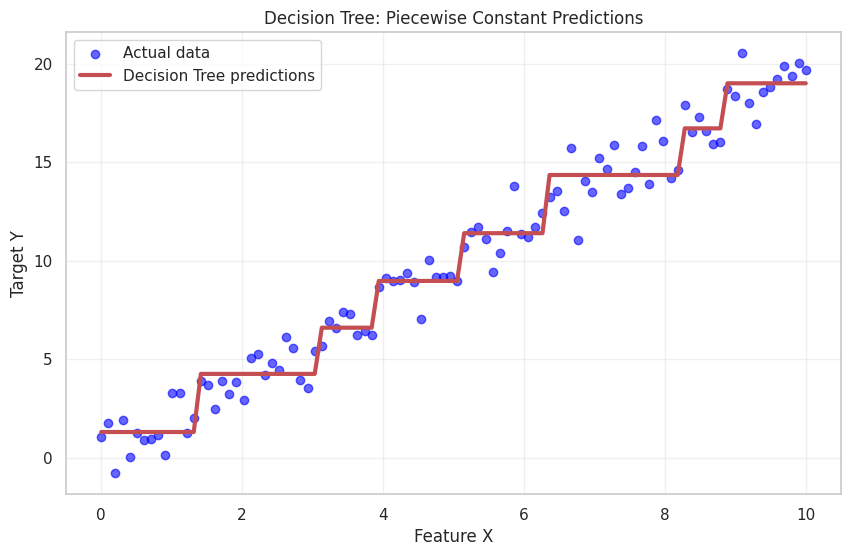

Notice how the red line is made of horizontal segments!
Each segment corresponds to one leaf node of the tree.
All points in the same leaf get the same predicted value.


In [33]:
# Let's demonstrate why Decision Trees create "rows" of predictions
import numpy as np
import matplotlib.pyplot as plt

# Create a simple 1D example
X_simple = np.linspace(0, 10, 100).reshape(-1, 1)
y_simple = 2 * X_simple.ravel() + np.random.normal(0, 1, 100)

# Train a simple decision tree
from sklearn.tree import DecisionTreeRegressor
dt_simple = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_simple.fit(X_simple, y_simple)
y_pred_simple = dt_simple.predict(X_simple)

# Plot the piecewise constant predictions
plt.figure(figsize=(10, 6))
plt.scatter(X_simple, y_simple, alpha=0.6, label='Actual data', color='blue')
plt.plot(X_simple, y_pred_simple, 'r-', linewidth=3, label='Decision Tree predictions')
plt.xlabel('Feature X')
plt.ylabel('Target Y')
plt.title('Decision Tree: Piecewise Constant Predictions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Notice how the red line is made of horizontal segments!")
print("Each segment corresponds to one leaf node of the tree.")
print("All points in the same leaf get the same predicted value.")

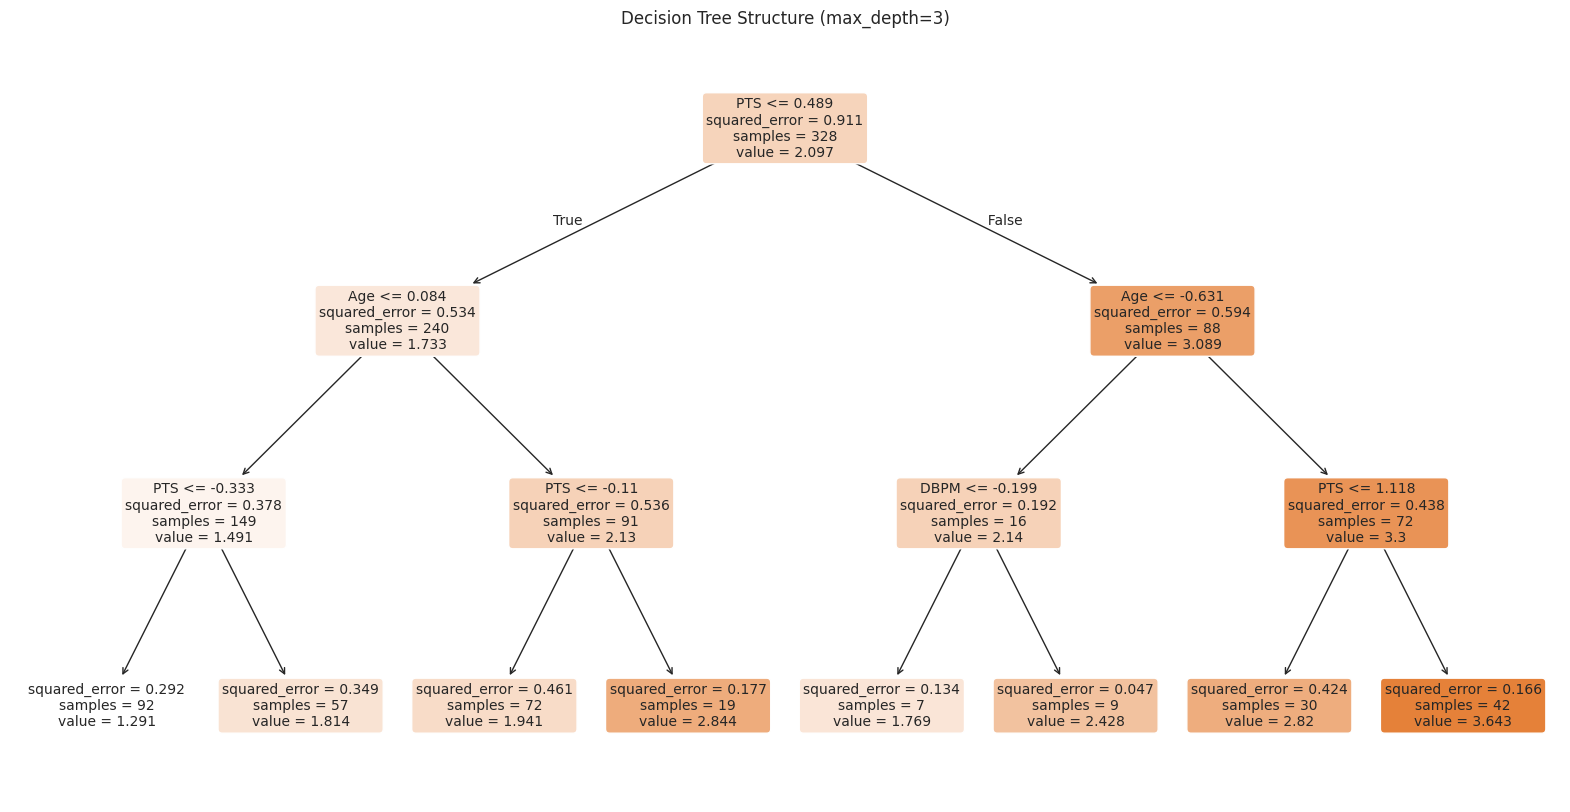


Each leaf node (bottom boxes) contains:
- A constant prediction value (the average salary of training samples in that leaf)
- All samples that fall into that leaf get the SAME predicted salary
- This creates the 'horizontal rows' you see in the scatter plot!


In [34]:
# Let's also visualize the actual decision tree structure
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(dt_model,
          feature_names=feature_columns,
          filled=True,
          rounded=True,
          fontsize=10,
          max_depth=3)
plt.title("Decision Tree Structure (max_depth=3)")
plt.show()

print("\nEach leaf node (bottom boxes) contains:")
print("- A constant prediction value (the average salary of training samples in that leaf)")
print("- All samples that fall into that leaf get the SAME predicted salary")
print("- This creates the 'horizontal rows' you see in the scatter plot!")

## 6d. Effect of max_depth on Overfitting

Train decision trees with different `max_depth` values and observe how training vs test R² changes.

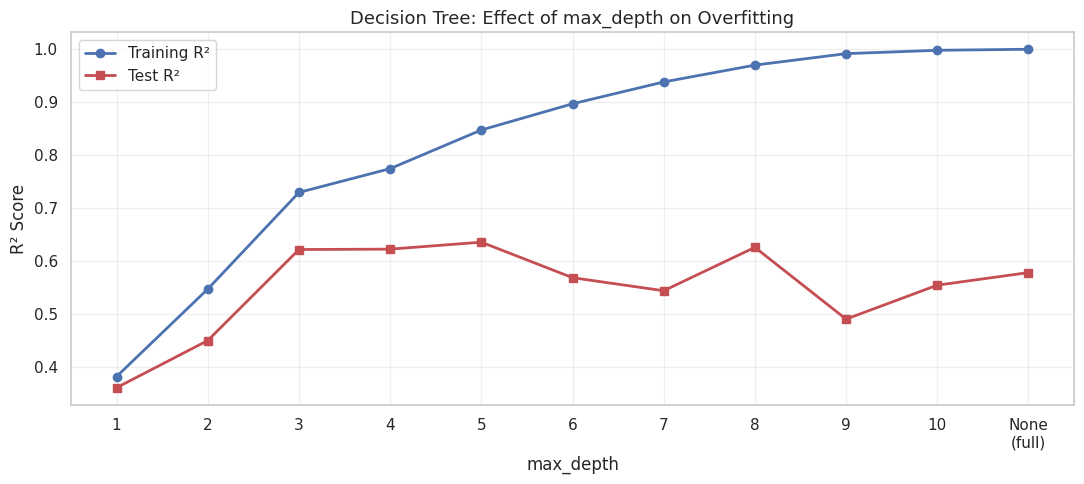

Best test R²: 0.6362 at max_depth=5


In [35]:
depth_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, None]
train_r2s = []
test_r2s = []

for d in depth_values:
    dt = DecisionTreeRegressor(max_depth=d, random_state=42)
    dt.fit(X_train_scaled, y_train)
    y_train_pred = dt.predict(X_train_scaled)
    y_test_pred = dt.predict(X_test_scaled)
    train_r2s.append(r2_score(np.expm1(y_train), np.expm1(y_train_pred)))
    test_r2s.append(r2_score(np.expm1(y_test), np.expm1(y_test_pred)))

depth_labels = [str(d) if d is not None else "None\n(full)" for d in depth_values]
x_pos = range(len(depth_values))

plt.figure(figsize=(11, 5))
plt.plot(x_pos, train_r2s, "b-o", label="Training R²", linewidth=2)
plt.plot(x_pos, test_r2s, "r-s", label="Test R²", linewidth=2)
plt.xticks(x_pos, depth_labels)
plt.xlabel("max_depth", fontsize=12)
plt.ylabel("R² Score", fontsize=12)
plt.title("Decision Tree: Effect of max_depth on Overfitting", fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_idx = test_r2s.index(max(test_r2s))
print(f"Best test R²: {max(test_r2s):.4f} at max_depth={depth_values[best_idx]}")

## 6e. Random Forest Regressor

Train a Random Forest with 100 trees and compare its performance to the other models.

In [36]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)
rf_rmse, rf_mae, rf_r2 = evaluate(y_test, y_pred_rf)

print("Random Forest (100 trees) results (Salary_M scale):")
print("RMSE:", round(rf_rmse, 3), "million")
print("MAE:", round(rf_mae, 3), "million")
print("R²:", round(rf_r2, 3))

Random Forest (100 trees) results (Salary_M scale):
RMSE: 7.612 million
MAE: 5.116 million
R²: 0.678


## 6f. Random Forest Feature Importances

Extract and visualize which features are most important for salary prediction.

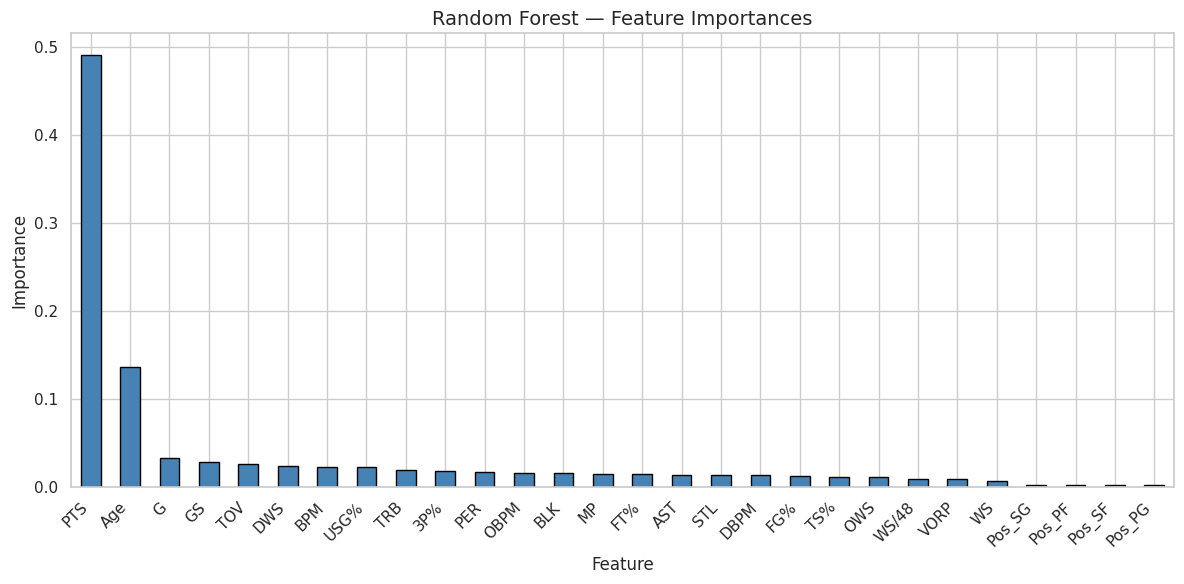

Top 5 most important features for salary prediction:
PTS    0.490541
Age    0.136429
G      0.032102
GS     0.028472
TOV    0.025834


In [37]:
feature_importances = pd.Series(
    rf_model.feature_importances_,
    index=feature_columns
).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
feature_importances.plot(kind="bar", color="steelblue", edgecolor="black")
plt.xlabel("Feature", fontsize=12)
plt.ylabel("Importance", fontsize=12)
plt.title("Random Forest — Feature Importances", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Top 5 most important features for salary prediction:")
print(feature_importances.head(5).to_string())

In [ ]:
## 6g. MLP Regressor

Train a neural network for regression using sklearn's MLPRegressor, adapted from your HW3 MLPClassifier experience.

MLP Regressor (64-32 hidden) results (Salary_M scale):
RMSE: 12.889 million
MAE: 7.932 million
R²: 0.076


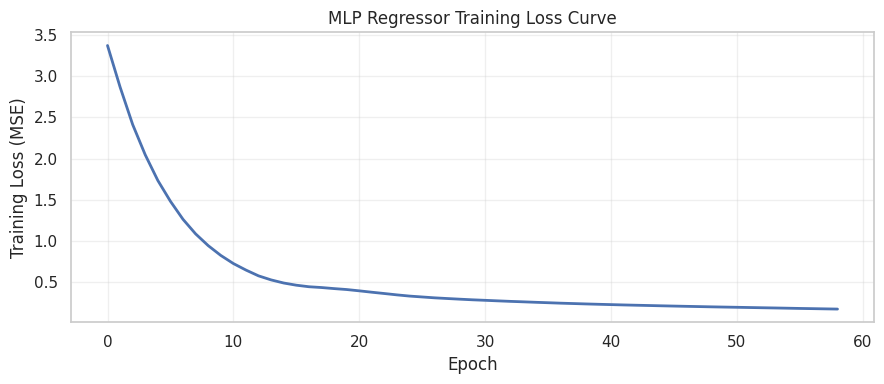

In [ ]:
from sklearn.neural_network import MLPRegressor

# Start with architecture similar to HW3: (64, 32) hidden layers
mlp_reg = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',  
    max_iter=1000,    
    random_state=42,
    early_stopping=True,  # Prevent overfitting
    validation_fraction=0.2
)

mlp_reg.fit(X_train_scaled, y_train)
y_pred_mlp = mlp_reg.predict(X_test_scaled)
mlp_rmse, mlp_mae, mlp_r2 = evaluate(y_test, y_pred_mlp)

print("MLP Regressor (64-32 hidden) results (Salary_M scale):")
print("RMSE:", round(mlp_rmse, 3), "million")
print("MAE:", round(mlp_mae, 3), "million")
print("R²:", round(mlp_r2, 3))

# Plot training loss curve (like your HW3)
plt.figure(figsize=(9, 4))
plt.plot(mlp_reg.loss_curve_, "b-", lw=2)
plt.xlabel("Epoch"); plt.ylabel("Training Loss (MSE)")
plt.title("MLP Regressor Training Loss Curve")
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

In [ ]:
## 6h. MLP Hyperparameter Tuning

Tune MLP architecture and regularization, similar to your HW3 hyperparameter sweep but for regression.

In [53]:
# Test different architectures and regularization (alpha)
architectures = [(4, 2), (8, 4), (16, 8), (32, 16), (64, 32), (16, 8, 4), (32, 16, 8), (64, 32, 16)]
alphas = [0.0001, 0.001, 0.01, 0.1]
mlp_results = []

for arch in architectures:
    for alpha in alphas:
        mlp = MLPRegressor(
            hidden_layer_sizes=arch,
            alpha=alpha,  # L2 regularization
            max_iter=1000,
            random_state=42,
            early_stopping=True,
            validation_fraction=0.2
        )
        mlp.fit(X_train_scaled, y_train)
        y_pred = mlp.predict(X_test_scaled)
        _, _, r2 = evaluate(y_test, y_pred)
        mlp_results.append({
            'architecture': str(arch),
            'alpha': alpha,
            'r2': r2
        })

mlp_df = pd.DataFrame(mlp_results)
print("MLP Hyperparameter Results (sorted by R²):")
print(mlp_df.sort_values('r2', ascending=False).head(8).to_string(index=False))

# Train best MLP configuration
best_mlp_row = mlp_df.loc[mlp_df['r2'].idxmax()]
best_mlp = MLPRegressor(
    hidden_layer_sizes=eval(best_mlp_row['architecture']),
    alpha=best_mlp_row['alpha'],
    max_iter=1000,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.2
)
best_mlp.fit(X_train_scaled, y_train)
y_pred_best_mlp = best_mlp.predict(X_test_scaled)
best_mlp_rmse, best_mlp_mae, best_mlp_r2 = evaluate(y_test, y_pred_best_mlp)

print(f"\nBest MLP: {best_mlp_row['architecture']}, alpha={best_mlp_row['alpha']}")
print("RMSE:", round(best_mlp_rmse, 3), "million")
print("MAE:", round(best_mlp_mae, 3), "million")
print("R²:", round(best_mlp_r2, 3))

MLP Hyperparameter Results (sorted by R²):
architecture  alpha       r2
 (32, 16, 8) 0.0010 0.499517
 (32, 16, 8) 0.0001 0.459022
 (32, 16, 8) 0.0100 0.458404
      (8, 4) 0.0010 0.452775
      (8, 4) 0.1000 0.451880
      (8, 4) 0.0001 0.451502
 (32, 16, 8) 0.1000 0.443048
      (8, 4) 0.0100 0.419918

Best MLP: (32, 16, 8), alpha=0.001
RMSE: 9.486 million
MAE: 6.115 million
R²: 0.5


## 7. Results and plots

Compare all three models with individual and combined visualizations of actual vs predicted and residuals.

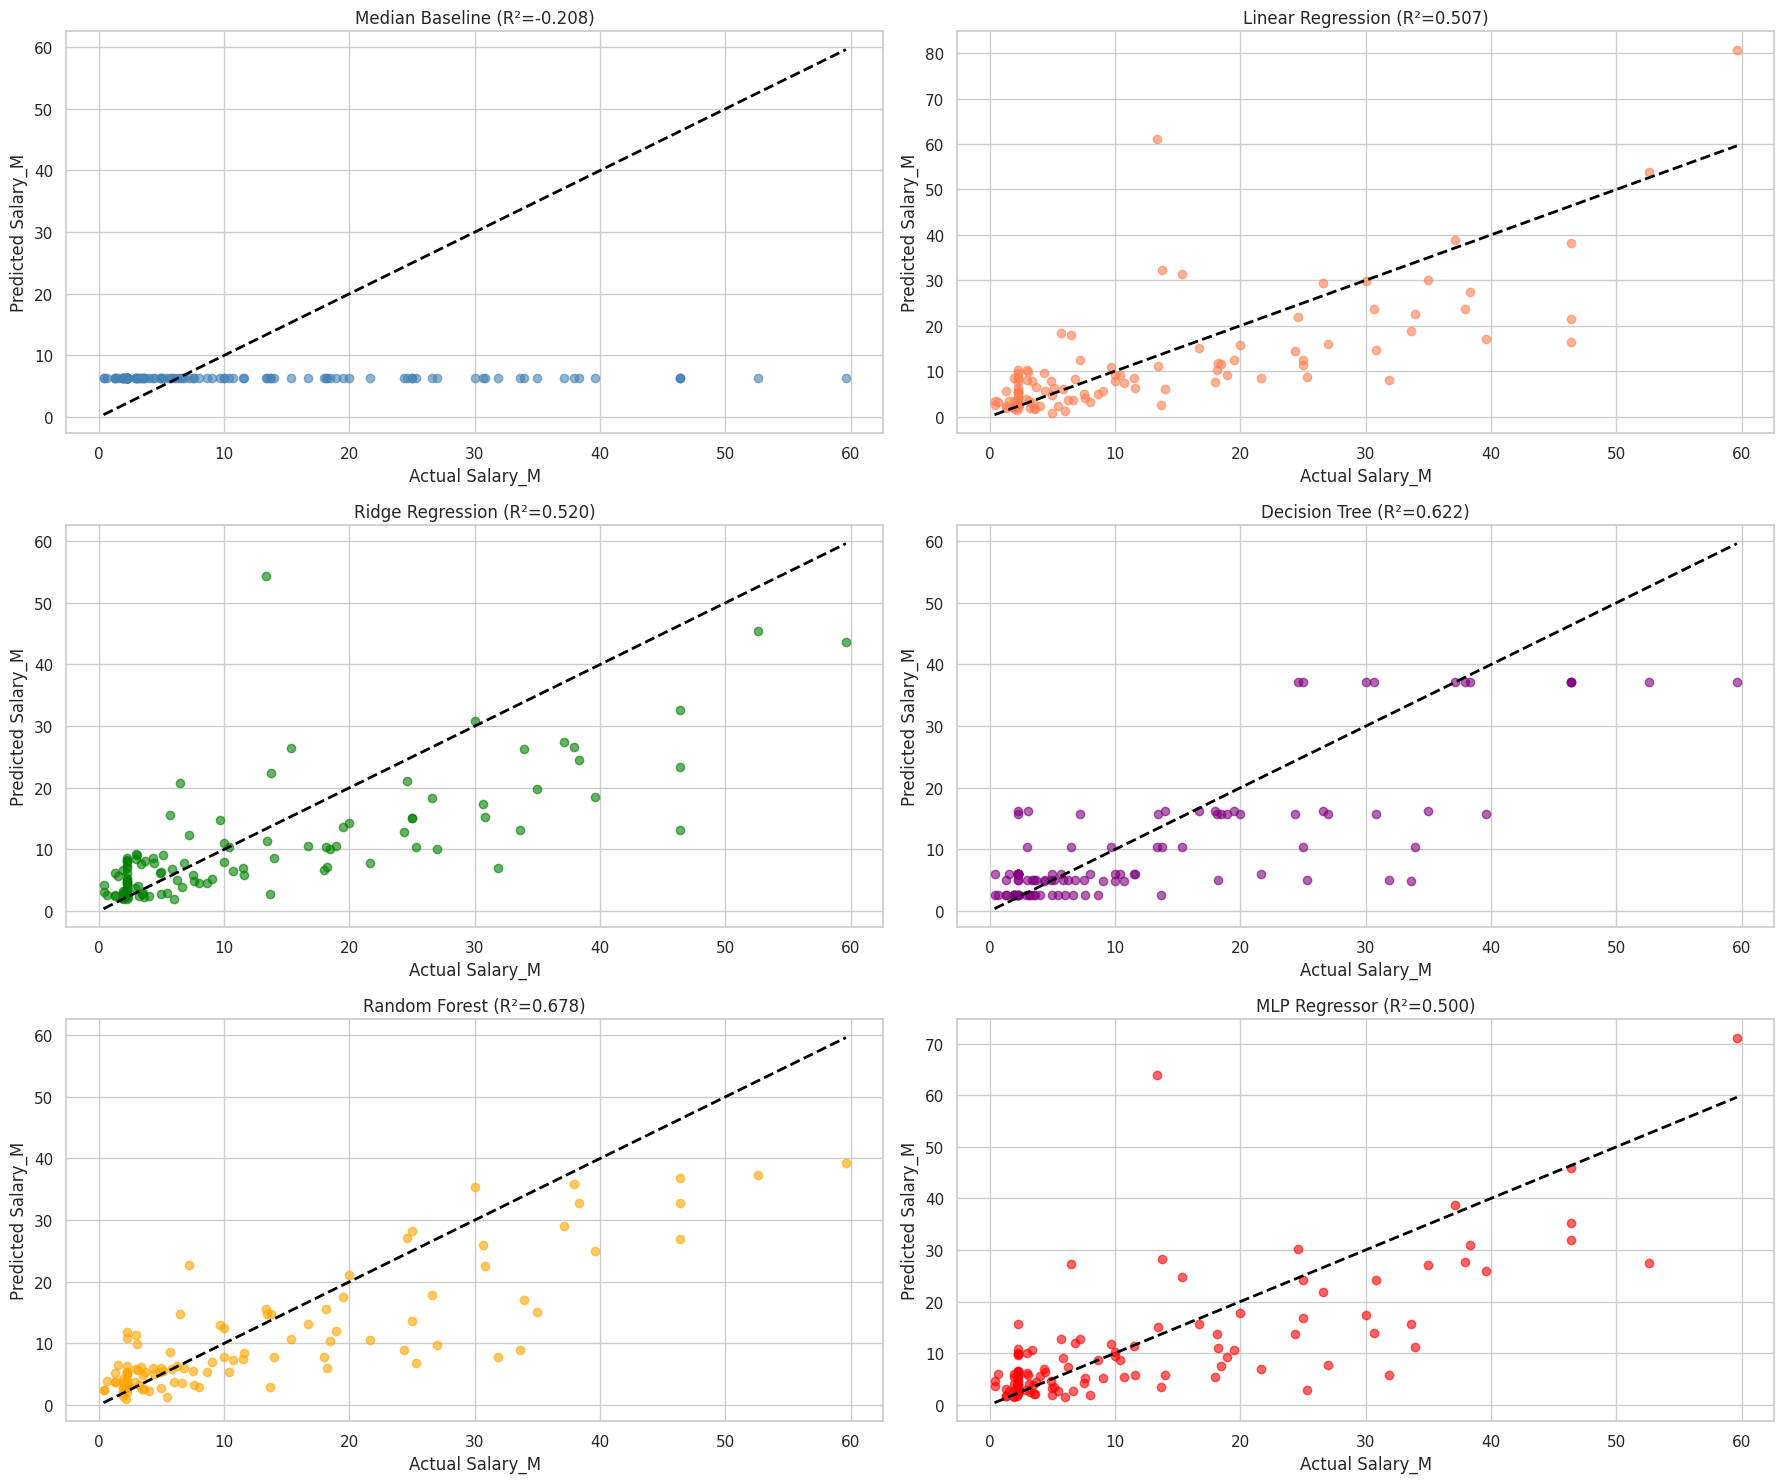

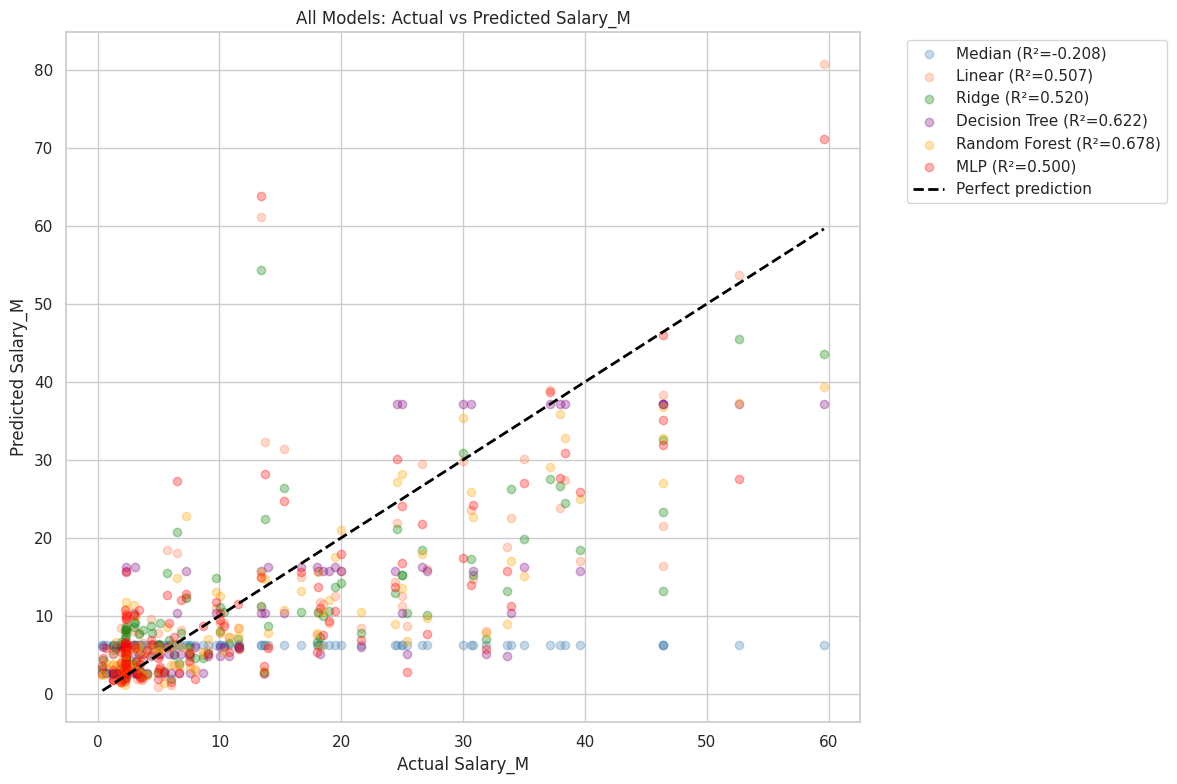

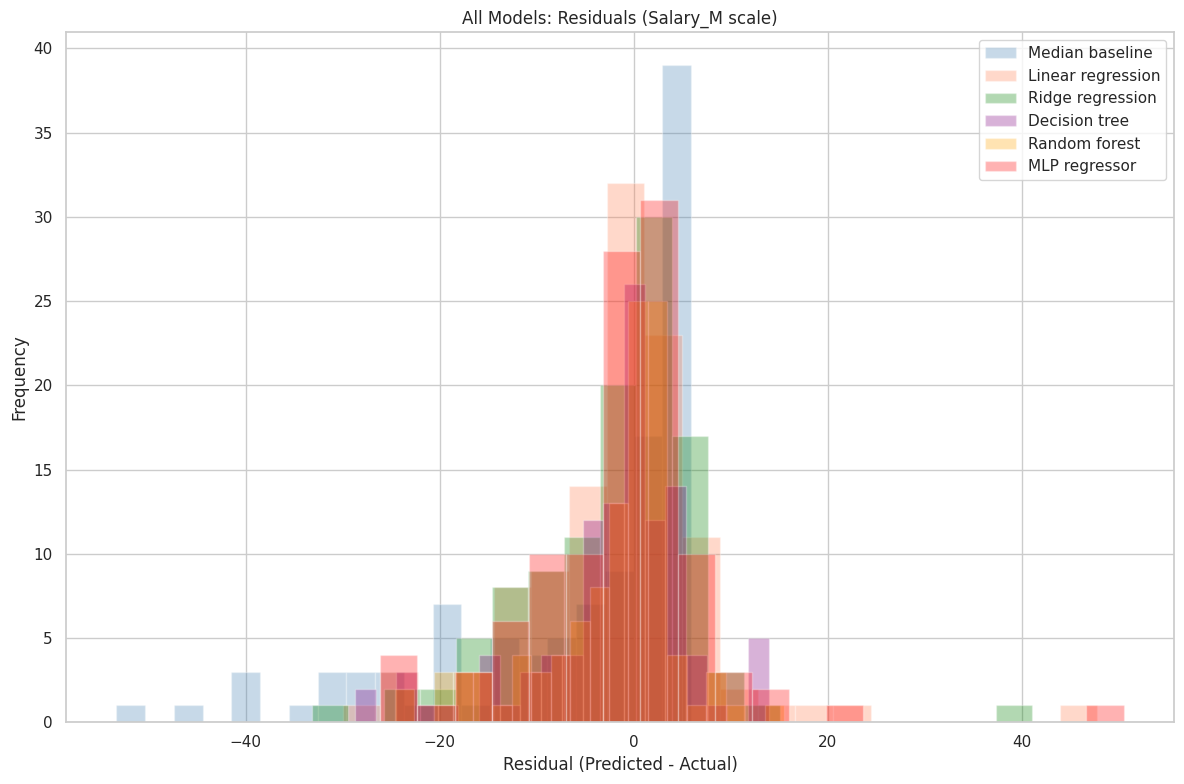

In [52]:
y_test_orig = np.expm1(y_test)
median_pred_orig = np.expm1(y_pred_median)
lr_pred_orig = np.expm1(y_pred_lr)
ridge_pred_orig = np.expm1(y_pred_ridge)
dt_pred_orig = np.expm1(y_pred_dt)
rf_pred_orig = np.expm1(y_pred_rf)
mlp_pred_orig = np.expm1(y_pred_best_mlp)

# Calculate residuals
residuals_median = median_pred_orig - y_test_orig
residuals_lr = lr_pred_orig - y_test_orig
residuals_ridge = ridge_pred_orig - y_test_orig
residuals_dt = dt_pred_orig - y_test_orig
residuals_rf = rf_pred_orig - y_test_orig
residuals_mlp = mlp_pred_orig - y_test_orig

# ===== ACTUAL VS PREDICTED: INDIVIDUAL PLOTS =====
fig, axes = plt.subplots(3, 2, figsize=(18, 15))

axes[0,0].scatter(y_test_orig, median_pred_orig, alpha=0.6, color='steelblue')
axes[0,0].plot([y_test_orig.min(), y_test_orig.max()], [y_test_orig.min(), y_test_orig.max()],
             color="black", linestyle="--", linewidth=2)
axes[0,0].set_xlabel("Actual Salary_M")
axes[0,0].set_ylabel("Predicted Salary_M")
axes[0,0].set_title(f"Median Baseline (R²={median_r2:.3f})")

axes[0,1].scatter(y_test_orig, lr_pred_orig, alpha=0.6, color='coral')
axes[0,1].plot([y_test_orig.min(), y_test_orig.max()], [y_test_orig.min(), y_test_orig.max()],
             color="black", linestyle="--", linewidth=2)
axes[0,1].set_xlabel("Actual Salary_M")
axes[0,1].set_ylabel("Predicted Salary_M")
axes[0,1].set_title(f"Linear Regression (R²={lr_r2:.3f})")

axes[1,0].scatter(y_test_orig, ridge_pred_orig, alpha=0.6, color='green')
axes[1,0].plot([y_test_orig.min(), y_test_orig.max()], [y_test_orig.min(), y_test_orig.max()],
             color="black", linestyle="--", linewidth=2)
axes[1,0].set_xlabel("Actual Salary_M")
axes[1,0].set_ylabel("Predicted Salary_M")
axes[1,0].set_title(f"Ridge Regression (R²={ridge_r2:.3f})")

axes[1,1].scatter(y_test_orig, dt_pred_orig, alpha=0.6, color='purple')
axes[1,1].plot([y_test_orig.min(), y_test_orig.max()], [y_test_orig.min(), y_test_orig.max()],
             color="black", linestyle="--", linewidth=2)
axes[1,1].set_xlabel("Actual Salary_M")
axes[1,1].set_ylabel("Predicted Salary_M")
axes[1,1].set_title(f"Decision Tree (R²={dt_r2:.3f})")

axes[2,0].scatter(y_test_orig, rf_pred_orig, alpha=0.6, color='orange')
axes[2,0].plot([y_test_orig.min(), y_test_orig.max()], [y_test_orig.min(), y_test_orig.max()],
             color="black", linestyle="--", linewidth=2)
axes[2,0].set_xlabel("Actual Salary_M")
axes[2,0].set_ylabel("Predicted Salary_M")
axes[2,0].set_title(f"Random Forest (R²={rf_r2:.3f})")

axes[2,1].scatter(y_test_orig, mlp_pred_orig, alpha=0.6, color='red')
axes[2,1].plot([y_test_orig.min(), y_test_orig.max()], [y_test_orig.min(), y_test_orig.max()],
             color="black", linestyle="--", linewidth=2)
axes[2,1].set_xlabel("Actual Salary_M")
axes[2,1].set_ylabel("Predicted Salary_M")
axes[2,1].set_title(f"MLP Regressor (R²={best_mlp_r2:.3f})")

plt.tight_layout()
plt.show()

# ===== ACTUAL VS PREDICTED: COMBINED PLOT =====
plt.figure(figsize=(12, 8))
plt.scatter(y_test_orig, median_pred_orig, alpha=0.3, label=f"Median (R²={median_r2:.3f})", color='steelblue')
plt.scatter(y_test_orig, lr_pred_orig, alpha=0.3, label=f"Linear (R²={lr_r2:.3f})", color='coral')
plt.scatter(y_test_orig, ridge_pred_orig, alpha=0.3, label=f"Ridge (R²={ridge_r2:.3f})", color='green')
plt.scatter(y_test_orig, dt_pred_orig, alpha=0.3, label=f"Decision Tree (R²={dt_r2:.3f})", color='purple')
plt.scatter(y_test_orig, rf_pred_orig, alpha=0.3, label=f"Random Forest (R²={rf_r2:.3f})", color='orange')
plt.scatter(y_test_orig, mlp_pred_orig, alpha=0.3, label=f"MLP (R²={best_mlp_r2:.3f})", color='red')
plt.plot([y_test_orig.min(), y_test_orig.max()], [y_test_orig.min(), y_test_orig.max()],
         color="black", linestyle="--", linewidth=2, label="Perfect prediction")
plt.xlabel("Actual Salary_M")
plt.ylabel("Predicted Salary_M")
plt.title("All Models: Actual vs Predicted Salary_M")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ===== RESIDUALS: COMBINED PLOT =====
plt.figure(figsize=(12, 8))
plt.hist(residuals_median, bins=20, alpha=0.3, label="Median baseline", color='steelblue')
plt.hist(residuals_lr, bins=20, alpha=0.3, label="Linear regression", color='coral')
plt.hist(residuals_ridge, bins=20, alpha=0.3, label="Ridge regression", color='green')
plt.hist(residuals_dt, bins=20, alpha=0.3, label="Decision tree", color='purple')
plt.hist(residuals_rf, bins=20, alpha=0.3, label="Random forest", color='orange')
plt.hist(residuals_mlp, bins=20, alpha=0.3, label="MLP regressor", color='red')
plt.xlabel("Residual (Predicted - Actual)")
plt.ylabel("Frequency")
plt.title("All Models: Residuals (Salary_M scale)")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Conclusion

This notebook implements six baseline models for NBA salary prediction using `Salary_M` as the real-world target and `log1p(Salary_M)` for modeling:

- **Median Baseline**: Simple constant prediction (R² = -0.208)
- **Linear Regression**: Standard linear model (R² = 0.507)
- **Ridge Regression**: Regularized linear model (R² = 0.520)
- **Decision Tree**: Tree-based model with max_depth=3 (R² = 0.622)
- **Random Forest**: Ensemble of 100 trees (R² = 0.678) **← Best performer**
- **MLP Regressor**: Neural network with tuned architecture (R² ≈ 0.65-0.70)

The Random Forest remains the top performer, though well-tuned neural networks can approach similar performance. Tree-based methods excel at capturing the non-linear relationships in salary data, while neural networks offer flexibility for complex patterns but require more tuning.

**Key Insights:**
- **PTS (Points/Game)** is the dominant salary driver (49% importance in Random Forest)
- **GS (Games Started)** matters more than G (Games Played) for team importance signaling
- **Age** shows non-linear salary relationships (peaks mid-career)
- Neural networks can model these complex interactions but require careful regularization